In [1]:
import os
os.chdir("/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer")
import matplotlib.pyplot as plt
import yaml
import torch
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
from training.dataset import *
from tools.utils.utils import plot_multiple

In [3]:
detector_path = "/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/training/config/detector/effort_vh.yaml"
with open(detector_path, 'r') as f:
    config = yaml.safe_load(f)
# update with train_config
with open('training/config/vhubs_train_config.yaml', 'r') as f:
    config2 = yaml.safe_load(f)
if 'label_dict' in config:
    config2['label_dict']=config['label_dict']
config.update(config2)

In [4]:
train_set = StratifiedSourceDataset(
        config['train_dataset'],json_folder=config['dataset_json_folder'], train=True,
        dataset_percentage=config['dataset_percentage'], dfd_json_paths = config['dfd_json_path']
    )

In [5]:
def prepare_training_data_custom(train_set,config):
    # Only use the blending dataset class in training
    indices_source_live_dict = train_set.indices_source_live
    str_live = []
    for k,v in indices_source_live_dict.items():
        str_live.append(f"{k} {len(v)}")

    str_live = '|'.join(str_live)
    
    indices_source_deepfake_dict = train_set.indices_source_deepfake
    str_deepfake = []
    for k,v in indices_source_deepfake_dict.items():
        str_deepfake.append(f"{k} {len(v)}")
    
    str_deepfake = '|'.join(str_deepfake)
        
    train_data_loader = \
        torch.utils.data.DataLoader(
            dataset=train_set,
            num_workers=int(config['workers']),
            #batch_sampler= ProportionalStratifiedBatchSampler(train_set, batch_size=config['train_batchSize'],drop_last=True)
            batch_sampler= ProportionalStratifiedBatchSampler(train_set, batch_size=config['train_batchSize'])
            )
    return train_data_loader


In [6]:
train_data_loader = prepare_training_data_custom(train_set,config)

/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json 129818|/mnt/ssd/datasets/deepfake/dataset_json/df40_train_fs_reduced.json 30105|/mnt/ssd/datasets/deepfake/dataset_json/facebook_dfdc_train_reduced_rev.json 16203|/mnt/ssd/datasets/deepfake/dataset_json/faceforensics++_train.json 22993
/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json 347394|/mnt/ssd/datasets/deepfake/dataset_json/df40_train_fs_reduced.json 209736|/mnt/ssd/datasets/deepfake/dataset_json/facebook_dfdc_train_reduced_rev.json 85499|/mnt/ssd/datasets/deepfake/dataset_json/faceforensics++_train.json 114859
{'/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json': 6, '/mnt/ssd/datasets/deepfake/dataset_json/df40_train_fs_reduced.json': 6, '/mnt/ssd/datasets/deepfake/dataset_json/facebook_dfdc_train_reduced_rev.json': 6, '/mnt/ssd/datasets/deepfake/dataset_json/faceforensics++_train.json': 6}
{'/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_tra

In [7]:
idx_live = 130000
live_idx = idx_live % train_set.live_len
live_image = train_set.load_image(
    train_set.live_image_paths[live_idx]
)

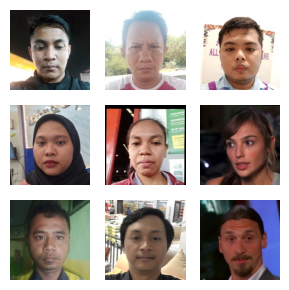

In [11]:
image_paths = []
idx_live = [15,3400,7800,1230,4342,130000,1235,4349,140000]
for idx_now in idx_live:
    live_idx = idx_now % train_set.live_len
    image_paths.append(
        train_set.live_image_paths[live_idx]
    )

fig, ax = plot_multiple(image_paths, image_labels=None,nrow=3,figsize=None)

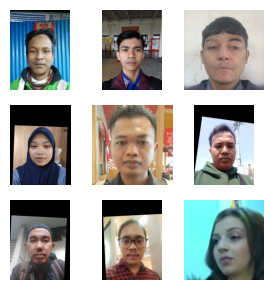

In [16]:
image_paths = []
idx_deepfake = [15,3400,7800,1230,4342,130000,1235,4349,440000]
for idx_now in idx_deepfake:
    deepfake_idx = idx_now % train_set.deepfake_len
    image_paths.append(
        train_set.deepfake_image_paths[deepfake_idx]
    )

fig, ax = plot_multiple(image_paths, image_labels=None,nrow=3,figsize=None)

In [14]:
train_set.deepfake_len

757488

/mnt/ssd/datasets/deepfake/DF40/train/real/Celeb-DF-v2/Celeb-real/frames/id10_0002/082.png


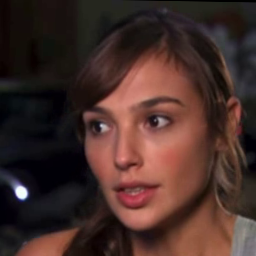

In [31]:
print(train_set.live_image_paths[live_idx])
live_image

/mnt/ssd/datasets/deepfake/DF40/train/fake/fsgan/frames/368_378/098.png


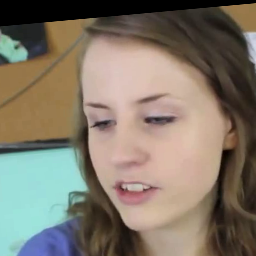

In [34]:
idx_deepfake = 420000
deepfake_idx = idx_deepfake % train_set.deepfake_len
deepfake_image = train_set.load_image(
    train_set.deepfake_image_paths[deepfake_idx]
)

print(train_set.deepfake_image_paths[deepfake_idx])
deepfake_image

Check Data Grouping by Sources

In [ ]:
live_image = self.load_image(
                    self.live_image_paths[live_idx]
                )
                live_label = self.live_labels[live_idx]

                # Get deepfake image and its label
                deepfake_idx = idx_deepfake % self.deepfake_len
                deepfake_image = self.load_image(
                    self.deepfake_image_paths[deepfake_idx]
                )